### Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Load the CFPB dataset

In [5]:
df = pd.read_csv(r"C:\Users\Administrator\Downloads\week7\Intelligent_Complaint_Analysis_for_Financial_Services\data\raw\complaints.csv")


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6156\2025641863.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Administrator\Downloads\week7\Intelligent_Complaint_Analysis_for_Financial_Services\data\raw\complaints.csv")


In [7]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [9]:
df.shape

(9609797, 18)

In [10]:
df.columns


Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

### Initial EDA (Understand the data)

#### Product distribution

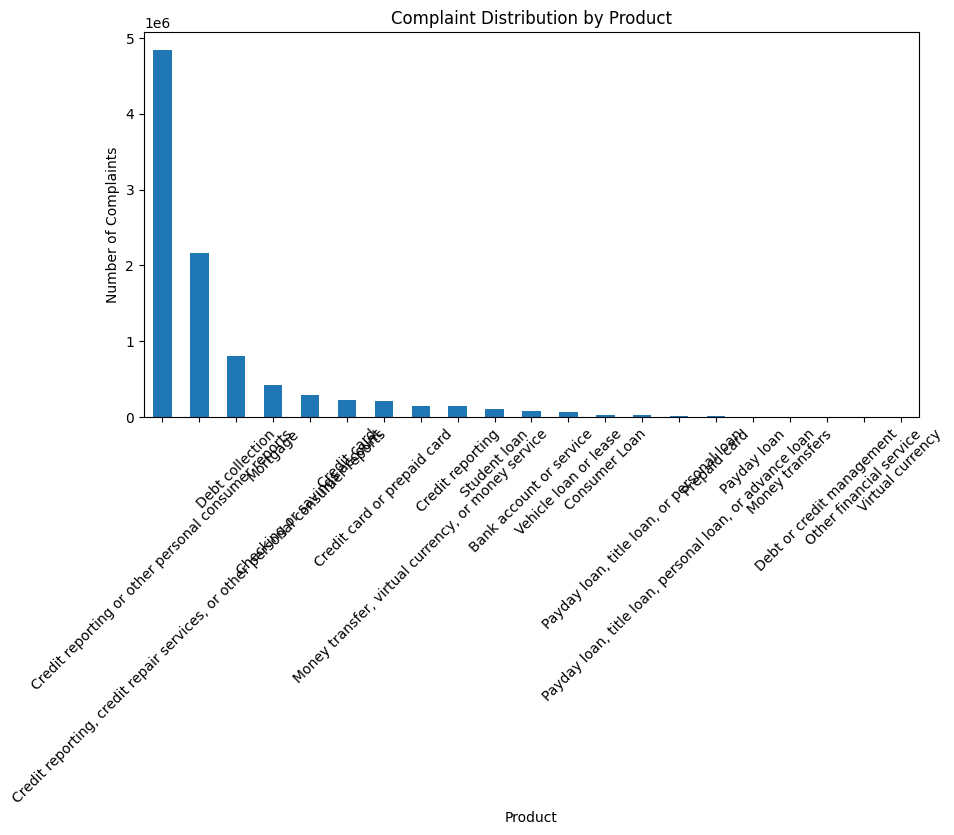

In [11]:
plt.figure(figsize=(10,5))
df['Product'].value_counts().plot(kind='bar')
plt.title("Complaint Distribution by Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()


### Complaints with vs without narratives

In [12]:
df['has_narrative'] = df['Consumer complaint narrative'].notna()

df['has_narrative'].value_counts()


has_narrative
False    6629041
True     2980756
Name: count, dtype: int64

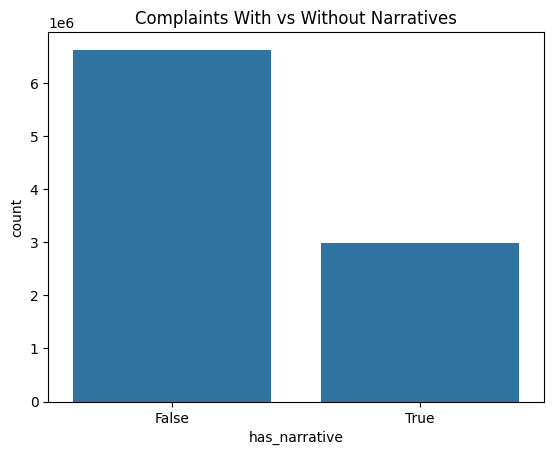

In [13]:
sns.countplot(x='has_narrative', data=df)
plt.title("Complaints With vs Without Narratives")
plt.show()


### Narrative length analysis

In [14]:
df['narrative_word_count'] = (
    df['Consumer complaint narrative']
    .fillna("")
    .apply(lambda x: len(x.split()))
)


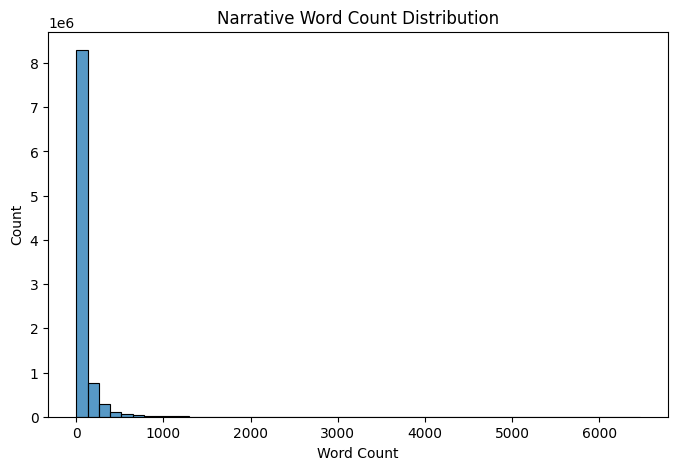

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['narrative_word_count'], bins=50)
plt.title("Narrative Word Count Distribution")
plt.xlabel("Word Count")
plt.show()


### Filter to required products only

In [16]:
target_products = [
    "Credit card",
    "Personal loan",
    "Buy Now, Pay Later (BNPL)",
    "Savings account",
    "Money transfer"
]


In [17]:
df_filtered = df[df['Product'].isin(target_products)]
df_filtered.shape
df_filtered['Product'].value_counts()


Product
Credit card    226686
Name: count, dtype: int64

### Remove empty narratives

In [18]:
df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].notna()
]

df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].str.strip() != ""
]


### Clean complaint narratives (VERY IMPORTANT)

##### Define cleaning function

In [19]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # remove special chars
    text = re.sub(r"\s+", " ", text).strip()
    
    # remove boilerplate phrases
    boilerplate = [
        "i am writing to file a complaint",
        "this complaint is regarding",
        "please help me"
    ]
    for phrase in boilerplate:
        text = text.replace(phrase, "")
    
    return text


#### Apply cleaning

In [20]:
df_filtered['clean_narrative'] = (
    df_filtered['Consumer complaint narrative']
    .apply(clean_text)
)


In [21]:
df_filtered[['Consumer complaint narrative', 'clean_narrative']].head()


,Consumer complaint narrative,clean_narrative
12237,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...
14249,"Although the account had been deemed closed, I...",although the account had been deemed closed i ...


#### Save cleaned dataset (FINAL DELIVERABLE)

In [23]:
df_filtered.to_csv(
    r"C:\Users\Administrator\Downloads\week7\Intelligent_Complaint_Analysis_for_Financial_Services\data\processed/filtered_complaints.csv",
    index=False
)
